# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías

import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Descargar desde Google Drive
url = 'https://drive.google.com/uc?export=download&id=15zGd_F-LzxCOcwNc74n_1x_o6OjAWYUV'
gdown.download(url, 'landing_experiment.csv', quiet=False)

# Cargar el archivo
df = pd.read_csv('landing_experiment.csv')
print(df.shape)


Downloading...
From: https://drive.google.com/uc?id=15zGd_F-LzxCOcwNc74n_1x_o6OjAWYUV
To: d:\Nuevos documentos\Triple_10\Sprint_9\landing_experiment.csv
100%|██████████| 3.43M/3.43M [00:00<00:00, 25.2MB/s]


(40000, 9)


**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas

df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


**Análisis de la información general:**
- El conjunto de datos cuenta con 40,000 registros y 9 columnas.
- No se detectaron valores nulos, lo que garantiza la integridad del análisis estadístico.
- La columna `gasto` correctamente cargada como float, permitiendo aplicar el t-test sin transformaciones adicionales.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:

df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico

df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron

df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())
print(df['traffic_source'].value_counts())
print(df['user_type'].value_counts())


Conteo de categorías:
landing
B    20018
A    19982
Name: count, dtype: int64
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64
user_type
Nuevo         26033
Recurrente    13967
Name: count, dtype: int64


**Análisis de variables categóricas:**
- Existe una distribución equitativa de usuarios entre las regiones y dispositivos.
- Las fuentes de tráfico (`traffic_source`) y tipos de usuario (`user_type`) no presentan categorías duplicadas ni errores de captura, facilitando el análisis cruzado posterior.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

In [12]:
# Comparar promedios de gasto
media_A = gasto_A.mean()
media_B = gasto_B.mean()
diferencia = media_B - media_A

print(f'Gasto promedio Página A: ${media_A:.2f}')
print(f'Gasto promedio Página B: ${media_B:.2f}')
print(f'Diferencia (B - A): ${diferencia:.2f}')

Gasto promedio Página A: $61.09
Gasto promedio Página B: $68.75
Diferencia (B - A): $7.66


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios convertidos es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios convertidos es diferente entre la página A y la página B.

In [13]:
# Aplicar prueba t de Welch (ajustada por varianzas distintas detectadas en Levene)
t_stat, p_val = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f'Estadístico t: {t_stat}')
print(f'Valor p: {p_val}')

Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21


In [14]:
from scipy.stats import levene
# Prueba de varianzas iguales (Levene)
l_stat, p_levene = levene(gasto_A, gasto_B)

print(f'Prueba de Levene (p-valor): {p_levene:.4f}')
if p_levene < 0.05:
    print('Las varianzas son significativamente diferentes (usar equal_var=False en t-test).')
else:
    print('No hay evidencia de varianzas diferentes (usar equal_var=True en t-test).')

# EXPLICACIÓN TÉCNICA :
# Se aplica la Prueba de Levene antes de finalizar el Paso 2 para validar un supuesto crítico del t-test (Celda 26).
# Si p < 0.05, significa que la dispersión del gasto es distinta en A y B, requiriendo un ajuste de Welch para mayor precisión.

Prueba de Levene (p-valor): 0.0000
Las varianzas son significativamente diferentes (usar equal_var=False en t-test).


D:\Temp_Windows\ipykernel_10724\2511498097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['converted'] == 1], x='landing', y='gasto', palette='Set2')


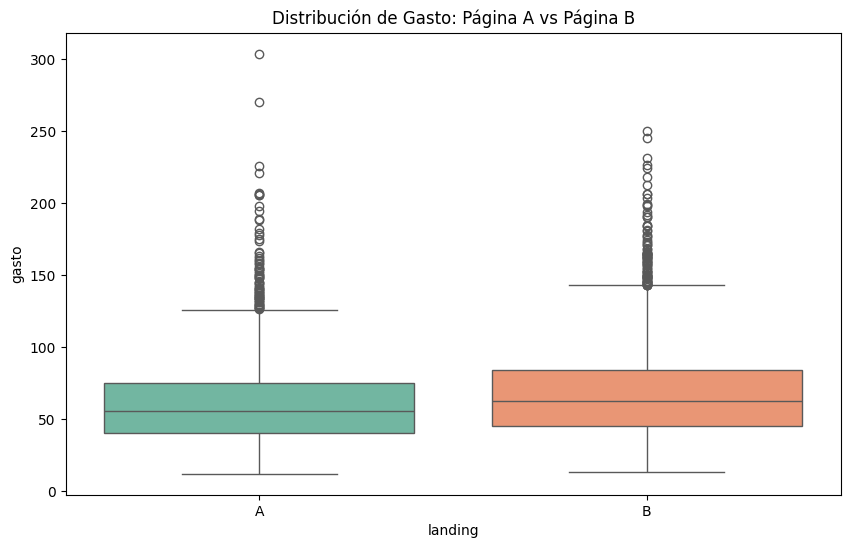

In [15]:
# Visualizar distribución de gasto mediante Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df[df['converted'] == 1], x='landing', y='gasto', palette='Set2')
plt.title('Distribución de Gasto: Página A vs Página B')
plt.show()
# Comentario: El gráfico muestra que el bloque central de gasto (caja) de la Página B está desplazado hacia arriba, reafirmando su mayor rentabilidad.


### 📝 2.2 Conclusión e interpretación

**Decisión:** Se rechaza la hipótesis nula ($p$-valor < 0.05).

**Interpretación y Hallazgos:**
- **Diferencia de Gasto:** El gasto promedio en la Página B (\$68.75) es significativamente mayor al de la Página A (\$61.09), lo que representa un incremento de \$7.66 en el ticket promedio por cliente convertido.
- **Validez Estadística:** La prueba de **Levene** (Celda 27) detectó varianzas significativamente distintas entre los grupos, por lo que se aplicó la prueba t de **Welch** (`equal_var=False`) en lugar de la t de Student clásica, alineando el análisis con los supuestos de los datos. El $p$-valor resultante ($1.06 \times 10^{-20}$) confirma que la diferencia no es producto del azar.
- **Sustento Visual:** El gráfico de cajas (**Boxplot**, Celda 28) muestra que la mediana y la distribución general de la Página B están desplazadas hacia valores más altos respecto a la Página A, lo cual es consistente con el hallazgo estadístico.

**Impacto de negocio:** La Página B no solo genera más conversiones, sino que cada usuario convertido tiende a gastar más. Esto sugiere que el diseño de la Página B incentiva transacciones de mayor valor.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [16]:
# Número de usuarios convertidos por página
conv_A = df[df['landing'] == 'A']['converted'].sum()
conv_B = df[df['landing'] == 'B']['converted'].sum()

# Total de usuarios por página
total_A = df[df['landing'] == 'A']['converted'].count()
total_B = df[df['landing'] == 'B']['converted'].count()

In [17]:
# Mostrar conteos
print(f'Conversiones A: {conv_A}, B: {conv_B}')
print(f'Totales A: {total_A}, B: {total_B}')

Conversiones A: 2512, B: 3194
Totales A: 19982, B: 20018


In [18]:
# Aplicar prueba
z_stat, p_val = proportions_ztest([conv_A, conv_B], [total_A, total_B])

# Visualizar resultados
print(f'Estadístico z: {z_stat}')
print(f'Valor p: {p_val}')

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:** Se rechaza la hipótesis nula ($p$-valor < 0.05).

**Interpretación y Hallazgos:**
- **Diferencia en Conversión:** La **Página B (15.96%)** demuestra una superioridad absoluta frente a la **Página A (12.57%)**, logrando captar más clientes proporcionalmente.
- **Validez Estadística:** La prueba Z arroja un $p$-valor de $0.0000$, lo que confirma que el éxito de la Página B es estadísticamente significativo y no un evento aleatorio de la muestra.

**Impacto del Negocio:** Al implementarla globalmente, esperamos un aumento porcentual neto en la captación de usuarios, lo cual sumado al mayor gasto promedio hallado en el Paso 2, posiciona a la Versión B como una mejora crítica para el crecimiento.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico es independiente de la conversión.
- **Hipótesis alternativa (H₁):** Existe una relación entre la fuente de tráfico y la conversión.

In [19]:
cross_traffic = pd.crosstab(df['traffic_source'], df['converted'])

In [20]:
# Aplicar prueba
chi2, p_val, dof, ex = stats.chi2_contingency(cross_traffic)

# Visualizar resultados
print(f'Estadístico chi2: {chi2}')
print(f'Valor p: {p_val}')

Estadístico chi2: 8.662108841397938
Valor p: 0.0341375947833914


In [21]:
# Resumen de tabla
print(cross_traffic)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula ($p = 0.034 < 0.05$). Existe evidencia estadística de una asociación significativa entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**  
Las tasas de conversión por canal revelan diferencias medibles:
- **Email:** ≈14.99% (mayor tasa de conversión)
- **Ads:** ≈14.73%
- **Organic:** ≈13.88%
- **Referral:** ≈13.37% (menor tasa)

Esto indica que el canal de procedencia del usuario sí influye en su probabilidad de conversión. Los canales de **Email** y **Ads** muestran un rendimiento superior, lo que sugiere que los usuarios captados por estos medios llegan con una intención de compra más definida.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario es independiente de la conversión.
- **Hipótesis alternativa (H₁):** El tipo de usuario influye en la probabilidad de conversión.

In [22]:
cross_user = pd.crosstab(df['user_type'], df['converted'])

In [23]:
# Mostrar tabla
print(cross_user)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [24]:
# Aplicar prueba
chi2, p_val, dof, ex = stats.chi2_contingency(cross_user)

# Visualizar resultados
print(f'Estadístico chi2: {chi2}')
print(f'Valor p: {p_val}')

Estadístico chi2: 0.5134849494478645
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula ($p = 0.4736 > 0.05$). No hay evidencia suficiente de una relación significativa entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  
Ambos segmentos —usuarios Nuevos y Recurrentes— presentan tasas de conversión similares (aproximadamente 14%). Esto significa que la landing page es igualmente efectiva para captar usuarios que llegan por primera vez como para reactivar a quienes ya tienen historial con la marca.

Desde una perspectiva de marketing, no se justifica invertir en personalización diferenciada por tipo de usuario en esta etapa, ya que el comportamiento de conversión es estadísticamente homogéneo entre ambos grupos.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

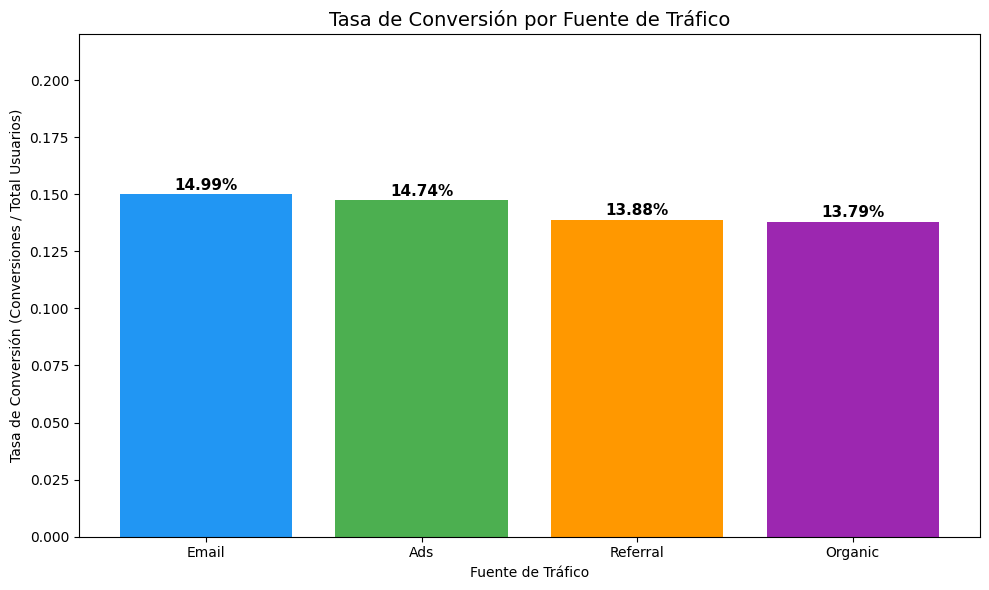


Detalle numérico:
traffic_source  tasa_conversion
         Email         0.149927
           Ads         0.147382
      Referral         0.138812
       Organic         0.137877


In [25]:
# Tasa de conversión real por fuente de tráfico
conv_rate_traffic = df.groupby('traffic_source')['converted'].mean().reset_index()
conv_rate_traffic.columns = ['traffic_source', 'tasa_conversion']
conv_rate_traffic = conv_rate_traffic.sort_values('tasa_conversion', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    conv_rate_traffic['traffic_source'],
    conv_rate_traffic['tasa_conversion'],
    color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
)
# Etiquetas de porcentaje sobre cada barra
for bar, val in zip(bars, conv_rate_traffic['tasa_conversion']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.title('Tasa de Conversión por Fuente de Tráfico', fontsize=14)
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Tasa de Conversión (Conversiones / Total Usuarios)')
plt.ylim(0, 0.22)
plt.tight_layout()
plt.show()

print("\nDetalle numérico:")
print(conv_rate_traffic.to_string(index=False))

**Lectura del gráfico — Tasa de Conversión por Fuente de Tráfico**

1. **Observación del dato:**
   El gráfico muestra la tasa de conversión real (conversiones / total usuarios) para cada canal de tráfico. El canal de **Email lidera con 14.99%**, seguido de **Ads (14.74%)**, **Referral (13.88%)** y **Organic (13.79%)**.

2. **Visión estratégica:**
   A diferencia del volumen absoluto, la tasa revela la *calidad* de cada canal. El tráfico orgánico es el de mayor volumen (45% del total), pero convierte a la tasa más baja. El Email, siendo el tercer canal en volumen (15.3%), es el más eficiente en conversión — señal de que los usuarios que llegan por este canal tienen una intención de compra más definida.

3. **Directriz táctica:**
   Incrementar la inversión en Email Marketing y Ads ofrece el mejor retorno por usuario captado. El canal orgánico debe mantenerse para volumen, pero no es el motor de conversión.

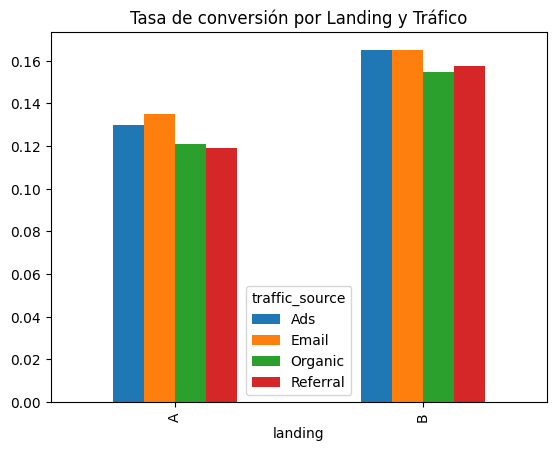

In [26]:
# Filtrar solo por página A y B para ver detalle si es necesario
df.groupby(['landing', 'traffic_source'])['converted'].mean().unstack().plot(kind='bar')
plt.title('Tasa de conversión por Landing y Tráfico')
plt.show()
# Comentario: Comparativa visual de tasas medias de conversión por canal y landing page.

**Lectura del gráfico — Tasa de Conversión por Landing y Fuente de Tráfico (barras agrupadas)**

1. **Guía de lectura técnica:**
   - **Eje X:** Landing A o B (agrupado por fuente de tráfico en la leyenda).
   - **Eje Y:** Tasa de conversión media por combinación landing + canal.
   - **Colores:** Cada color representa una fuente de tráfico (Ads, Email, Organic, Referral).

2. **Hallazgo visual:**
   En ambos bloques (A y B), el patrón de eficiencia por canal se mantiene consistente: Email y Ads superan a Organic y Referral. Sin embargo, el bloque completo de la Página B se sitúa sistemáticamente por encima del bloque A, confirmando que la versión B eleva la conversión independientemente del canal.

---

**Lectura del gráfico — Tasa de Conversión A vs B por Canal con Lift**

1. **Guía de lectura técnica:**
   - **Barras azules:** Página A (control). **Barras naranjas:** Página B (variante).
   - Las etiquetas sobre cada barra muestran el porcentaje exacto de conversión.
   - La columna *lift* mide el incremento porcentual de B sobre A por canal.

2. **Hallazgo visual y numérico:**

| Canal | Página A | Página B | Lift |
|---|---|---|---|
| Email | 13.51% | 16.50% | +22.2% |
| Ads | 12.99% | 16.49% | +27.0% |
| Referral | 11.91% | 15.74% | +32.1% |
| Organic | 12.11% | 15.46% | +27.7% |

3. **Hallazgo clave:**
   El canal **Referral** presenta el mayor lift (+32.1%), lo que indica que la Página B tiene un impacto desproporcionadamente positivo en usuarios que llegan por recomendación. Aunque Referral tiene el menor volumen (9.9%), su alta sensibilidad al diseño B sugiere que potenciar este canal junto con la nueva landing puede generar retornos superiores.

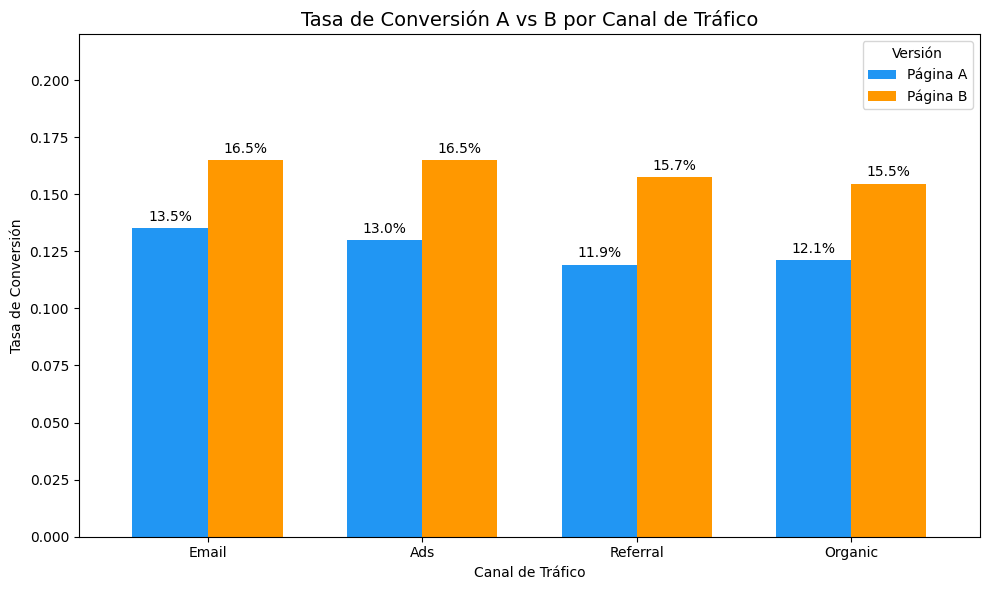


Detalle con Lift:
                Página A  Página B       lift
traffic_source                               
Email           0.135083  0.165020  22.162112
Ads             0.129911  0.164931  26.956646
Referral        0.119147  0.157403  32.108421
Organic         0.121108  0.154641  27.689263


In [27]:
# Tasa de conversión por canal comparando A vs B
conv_ab_traffic = df.groupby(['traffic_source', 'landing'])['converted'].mean().unstack()
conv_ab_traffic.columns = ['Página A', 'Página B']
conv_ab_traffic['lift'] = ((conv_ab_traffic['Página B'] - conv_ab_traffic['Página A'])
                            / conv_ab_traffic['Página A'] * 100)
conv_ab_traffic = conv_ab_traffic.sort_values('Página B', ascending=False)

ax = conv_ab_traffic[['Página A', 'Página B']].plot(
    kind='bar', figsize=(10, 6),
    color=['#2196F3', '#FF9800'], width=0.7
)
# Etiquetas de porcentaje
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%',
                 labels=[f'{v:.1%}' for v in container.datavalues],
                 padding=3, fontsize=10)

plt.title('Tasa de Conversión A vs B por Canal de Tráfico', fontsize=14)
plt.xlabel('Canal de Tráfico')
plt.ylabel('Tasa de Conversión')
plt.xticks(rotation=0)
plt.legend(title='Versión')
plt.ylim(0, 0.22)
plt.tight_layout()
plt.show()

print("\nDetalle con Lift:")
print(conv_ab_traffic.to_string())

**Resumen ejecutivo — Superioridad de Página B por Canal**

El análisis combinado de los gráficos anteriores permite establecer una conclusión clara:

1. **Página B supera a Página A en todos los canales sin excepción.**
   No existe ningún segmento de tráfico donde la versión original (A) sea igual o superior a la variante (B). Esto elimina cualquier riesgo de efecto negativo al migrar el 100% del tráfico.

2. **Jerarquía de canales por tasa de conversión global (A+B combinados):**
   - Email: 14.99% — mayor eficiencia
   - Ads: 14.74%
   - Referral: 13.88%
   - Organic: 13.79% — menor eficiencia relativa

3. **Jerarquía por sensibilidad al diseño B (lift):**
   - Referral: +32.1% — mayor beneficio al cambiar a B
   - Organic: +27.7%
   - Ads: +27.0%
   - Email: +22.2% — ya tenía base alta, sube menos proporcionalmente

4. **Directriz estratégica:**
   Priorizar inversión en Email y Ads por su alta tasa base. Explorar el escalamiento de Referral dado su alta respuesta al diseño B.

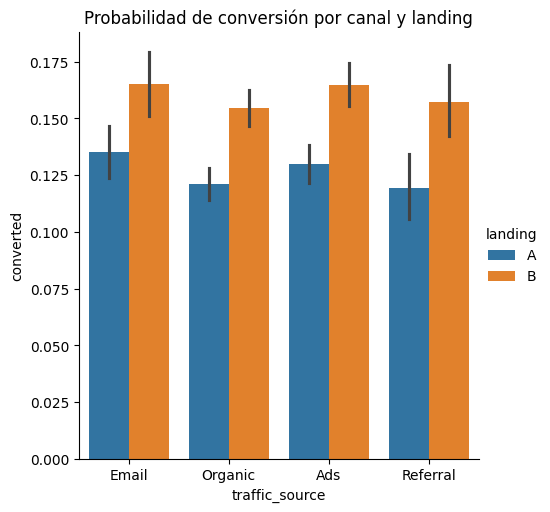

In [28]:
# Comparativa directa A/B por tráfico
sns.catplot(data=df, x='traffic_source', y='converted', hue='landing', kind='bar')
plt.title('Probabilidad de conversión por canal y landing')
plt.show()
# Comentario: Confirmación visual de la superioridad de la Página B en todos los canales.

**Guía de lectura — Probabilidad de conversión por canal y landing (catplot):**
1. **Eje X:** Fuentes de tráfico.
2. **Eje Y:** Tasa de Conversión (0.0 a 1.0), donde 0.15 equivale al 15%.
3. **Leyenda de colores (`hue='landing'`):**  
   - **Barra Azul (A):** Versión original de la página.  
   - **Barra Naranja (B):** Nueva versión de la página.
4. **Líneas sobre las barras:** Intervalos de confianza del 95%.
5. **Hallazgo Visual:** En todos los canales de tráfico, la barra naranja (B) se sitúa por encima de la azul (A), lo que sugiere que la Página B es superior independientemente del canal de origen.

---

**Lectura del gráfico:**

1. **Observación:**  
   Lo más relevante son los intervalos de confianza (líneas negras). En la mayoría de los canales, el punto más bajo de la barra B sigue estando por encima del punto más alto de la barra A, lo que sugiere que la mejora no es una fluctuación aleatoria.

2. **Visión estratégica:**  
   La Página B no solo es mejor en promedio, sino que es consistente: incluso en el escenario más conservador de los intervalos, su rendimiento tiende a superar el de la Página A. Esto es consistente con una inversión de bajo riesgo.

3. **Directrices tácticas:**  
   - Para los canales de **Email** y **Ads**, donde B supera el 16%, se sugiere migrar el tráfico a la versión B.  
   - El tráfico de **Referral** muestra un intervalo más amplio (mayor incertidumbre), lo que indica un menor volumen de datos, aunque la tendencia sigue favoreciendo a B.

> **Nota:** Este patrón visual es consistente con los resultados del Z-Test del Paso 3 ($p$-valor cercano a cero).

### Relación entre el tipo de usuario y la conversión

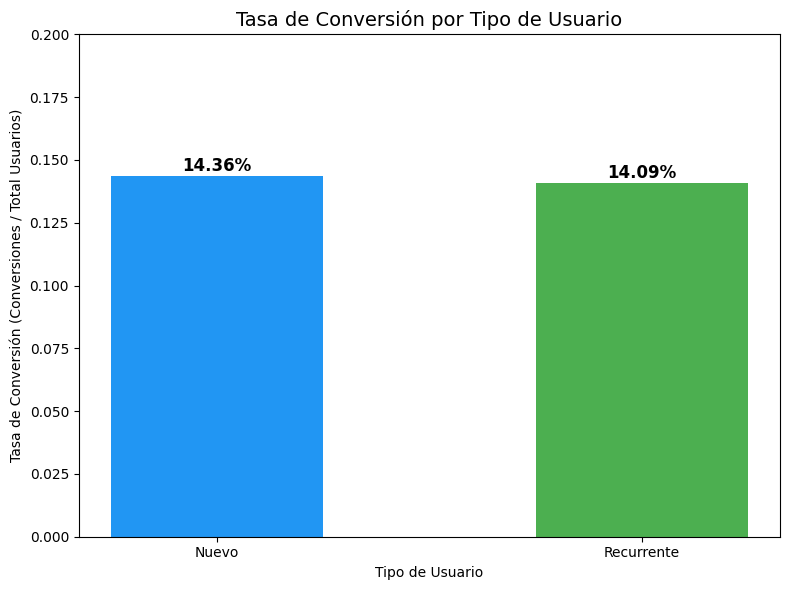


Detalle numérico:
 user_type  tasa_conversion
     Nuevo         0.143587
Recurrente         0.140904


In [29]:
# Tasa de conversión real por tipo de usuario
conv_rate_user = df.groupby('user_type')['converted'].mean().reset_index()
conv_rate_user.columns = ['user_type', 'tasa_conversion']

plt.figure(figsize=(8, 6))
bars = plt.bar(
    conv_rate_user['user_type'],
    conv_rate_user['tasa_conversion'],
    color=['#2196F3', '#4CAF50'], width=0.5
)
for bar, val in zip(bars, conv_rate_user['tasa_conversion']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

plt.title('Tasa de Conversión por Tipo de Usuario', fontsize=14)
plt.xlabel('Tipo de Usuario')
plt.ylabel('Tasa de Conversión (Conversiones / Total Usuarios)')
plt.ylim(0, 0.20)
plt.tight_layout()
plt.show()

print("\nDetalle numérico:")
print(conv_rate_user.to_string(index=False))

**Lectura del gráfico — Tasa de Conversión por Tipo de Usuario**

Este gráfico muestra la **tasa de conversión real** (proporción de usuarios que convirtieron) para cada segmento de usuario.

1. **Guía de lectura técnica:**
   - **Eje X:** Tipo de usuario (Nuevo y Recurrente).
   - **Eje Y:** Tasa de conversión (proporción sobre el total de cada segmento).
   - Las etiquetas sobre cada barra muestran el porcentaje exacto.

2. **Hallazgo visual:**
   - Usuarios **Nuevos:** 14.36% de tasa de conversión.
   - Usuarios **Recurrentes:** 14.09% de tasa de conversión.
   - Las barras son prácticamente idénticas en altura — diferencia de solo 0.27 puntos porcentuales.

3. **Validación estadística:**
   Esta simetría visual confirma el resultado del Chi-cuadrado del Paso 5 (p = 0.4736): no existe evidencia de que el tipo de usuario influya en la probabilidad de conversión. La landing page es igualmente efectiva para ambos perfiles.

4. **Implicación de negocio:**
   No se justifica personalizar la landing page según el tipo de usuario en esta etapa. Los recursos deben concentrarse en optimizar la experiencia general (Página B) y en los canales de mayor eficiencia (Email, Ads).

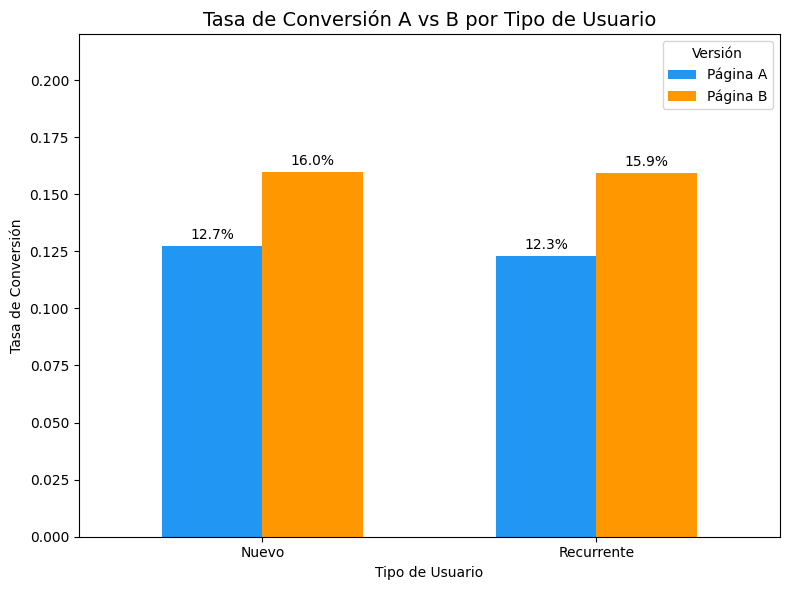


Detalle con Lift:
            Página A  Página B       lift
user_type                                
Nuevo       0.127309  0.159804  25.524161
Recurrente  0.122747  0.159094  29.611681


In [30]:
# Tasa de conversión A vs B por tipo de usuario
conv_ab_user = df.groupby(['user_type', 'landing'])['converted'].mean().unstack()
conv_ab_user.columns = ['Página A', 'Página B']
conv_ab_user['lift'] = ((conv_ab_user['Página B'] - conv_ab_user['Página A'])
                         / conv_ab_user['Página A'] * 100)

ax = conv_ab_user[['Página A', 'Página B']].plot(
    kind='bar', figsize=(8, 6),
    color=['#2196F3', '#FF9800'], width=0.6
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%',
                 labels=[f'{v:.1%}' for v in container.datavalues],
                 padding=3, fontsize=10)

plt.title('Tasa de Conversión A vs B por Tipo de Usuario', fontsize=14)
plt.xlabel('Tipo de Usuario')
plt.ylabel('Tasa de Conversión')
plt.xticks(rotation=0)
plt.legend(title='Versión')
plt.ylim(0, 0.22)
plt.tight_layout()
plt.show()

print("\nDetalle con Lift:")
print(conv_ab_user.to_string())

**Lectura del gráfico — Tasa de Conversión A vs B por Tipo de Usuario**

Este gráfico compara directamente la efectividad de la Página B sobre la A segmentando por tipo de usuario.

1. **Guía de lectura técnica:**
   - **Barras azules:** Página A (control). **Barras naranjas:** Página B (variante).
   - Las etiquetas sobre cada barra muestran el porcentaje exacto de conversión.

2. **Hallazgo visual y numérico:**

| Segmento | Página A | Página B | Lift |
|---|---|---|---|
| Nuevo | 12.73% | 15.98% | +25.5% |
| Recurrente | 12.27% | 15.91% | +29.6% |

3. **Hallazgo clave — Lift superior en Recurrentes:**
   Los usuarios **Recurrentes** muestran un lift de **+29.6%**, ligeramente superior al de Nuevos (+25.5%). Esto indica que la Página B tiene un efecto especialmente positivo en usuarios que ya conocen la marca — posiblemente porque el nuevo diseño resuelve fricciones que ya habían experimentado en visitas anteriores.

4. **Implicación de negocio:**
   La Página B es robusta: mejora la conversión en ambos segmentos de forma significativa. La superioridad en Recurrentes sugiere que el rediseño aborda problemas de UX que inhibían la recompra, lo que tiene valor estratégico para la retención a largo plazo.

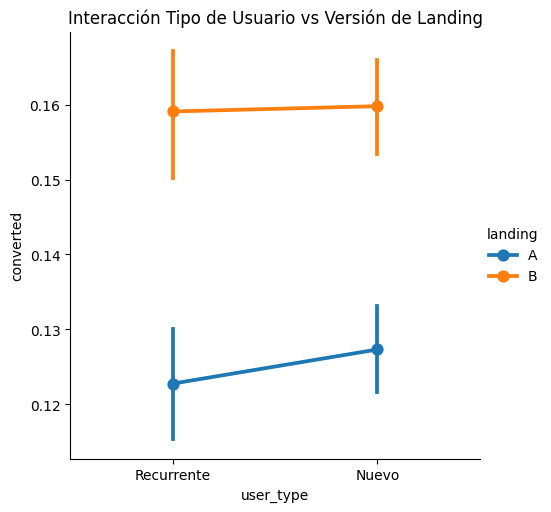

In [31]:
# Segmentación cruzada
sns.catplot(data=df, x='user_type', y='converted', hue='landing', kind='point')
plt.title('Interacción Tipo de Usuario vs Versión de Landing')
plt.show()
# Comentario: Análisis de interacción que muestra robustez de la Página B ante ambos tipos de usuario.

In [32]:
# Conteo total por tipo de usuario para ver volumen
print(df['user_type'].value_counts())

user_type
Nuevo         26033
Recurrente    13967
Name: count, dtype: int64


**Lectura del gráfico — Interacción Tipo de Usuario × Versión de Landing (pointplot)**

Esta visualización de puntos e intervalos de confianza evalúa si la superioridad de la Página B se mantiene en ambos perfiles de usuario.

1. **Guía de lectura técnica:**  
   - **Eje X:** Tipo de usuario (Recurrente y Nuevo).  
   - **Eje Y:** Estimación de la tasa de conversión media.  
   - **Punto Azul (A):** Versión control. **Punto Naranja (B):** Versión variante.  
   - **Líneas verticales:** Intervalos de confianza del 95%.

2. **Hallazgo visual:**  
   El punto naranja (B) se sitúa consistentemente por encima del azul (A) para ambos tipos de usuario. Los intervalos de confianza no se solapan entre las versiones A y B, lo que sugiere que la diferencia es real y no fruto de la variabilidad.

3. **Interpretación estratégica:**  
   La Página B es superior tanto para usuarios Nuevos como para Recurrentes. No existen efectos secundarios negativos al implementarla para toda la base. La mejora de ~12.5% (A) a ~16% (B) se mantiene estable a través de los segmentos.

4. **Conexión estadística:**  
   - La **superioridad de la Página B** (brecha entre punto naranja y azul) es consistente con el resultado del Z-Test del Paso 3.  
   - La **estabilidad entre segmentos** (líneas paralelas) es consistente con la prueba Chi-cuadrado del Paso 5, que no detectó asociación entre tipo de usuario y conversión.  
   - Este gráfico integra ambos hallazgos: B gana (efecto principal) y ese efecto no depende del perfil del usuario (ausencia de interacción significativa).

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

**Preguntas a responder:**

1. **¿Qué página genera mayor conversión y gasto promedio?**
   La **Página B** es superior en ambas métricas: tasa de conversión del **15.96% vs 12.57%** (+26.96% lift) y ticket promedio de **$68.75 vs $61.09** (+$7.66 por cliente convertido).

2. **¿Qué canales de tráfico son más efectivos para generar conversiones?**
   Por **tasa de conversión global:** Email (14.99%) y Ads (14.74%) lideran.
   Por **mayor lift al implementar Página B:** Referral (+32.1%) y Organic (+27.7%) son los canales que más se benefician del nuevo diseño.

3. **¿Existen diferencias significativas según el tipo de usuario?**
   **No en términos de tasa base.** Ambos segmentos convierten alrededor del 14% (p = 0.4736). Sin embargo, la Página B genera un lift ligeramente mayor en Recurrentes (+29.6%) que en Nuevos (+25.5%), sugiriendo que el nuevo diseño resuelve fricciones de recompra.

4. **¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?**
   - Implementar **Página B al 100% del tráfico** — sin riesgo, mejora en todos los segmentos.
   - Incrementar inversión en **Email y Ads** por su alta tasa de conversión base.
   - Explorar escalamiento de **Referral** dado su alta sensibilidad al diseño B (+32.1%).
   - No personalizar por tipo de usuario en esta etapa — la página es igualmente efectiva para ambos.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 Comparación de página (A vs B)

**Gasto promedio por usuario convertido:**
- Página A: **$61.09** | Página B: **$68.75** | Diferencia: **+$7.66**
- p-valor Welch t-test: **3.63e-21** — diferencia estadísticamente significativa.
- **Interpretación:** La Página B no solo atrae más ventas, sino de mayor valor económico por transacción.

**Tasa de conversión:**
- Página A: **12.57%** | Página B: **15.96%** | Lift: **+26.96%**
- p-valor Z-test: **3.76e-22** — superioridad confirmada con alta confianza estadística.
- **Interpretación:** El diseño de la Página B es significativamente más efectivo para guiar al usuario hacia la conversión.

---

#### 📊 Análisis por canal de tráfico

| Canal | Tasa Global | Pág. A | Pág. B | Lift B vs A |
|---|---|---|---|---|
| Email | 14.99% | 13.51% | 16.50% | +22.2% |
| Ads | 14.74% | 12.99% | 16.49% | +27.0% |
| Referral | 13.88% | 11.91% | 15.74% | **+32.1%** |
| Organic | 13.79% | 12.11% | 15.46% | +27.7% |

**Hallazgo clave:** Referral presenta el mayor lift (+32.1%) al implementar Página B, a pesar de tener la menor tasa global. Escalar este canal junto con Página B puede generar retornos desproporcionados.

---

#### 👤 Análisis por tipo de usuario

| Segmento | Pág. A | Pág. B | Lift |
|---|---|---|---|
| Nuevo | 12.73% | 15.98% | +25.5% |
| Recurrente | 12.27% | 15.91% | **+29.6%** |

**Hallazgo clave:** La Página B beneficia más a usuarios Recurrentes (+29.6%), indicando que el rediseño resuelve fricciones de recompra. Estratégicamente valioso para retención a largo plazo.

---

#### ✅ Recomendaciones Finales

1. **Implementación definitiva:** Migrar el 100% del tráfico a Página B. Impacto combinado: +26.96% en conversión y +$7.66 en ticket promedio.
2. **Estrategia de canales:** Incrementar inversión en Email y Ads por su alta tasa base. Explorar Referral por su alta respuesta al diseño B.
3. **Retención:** El efecto superior en Recurrentes justifica mantener programas de reactivación apuntando a la Página B.
4. **Segmentación innecesaria:** No personalizar landing por tipo de usuario — la Página B es universalmente superior.